In [1]:
import numpy as np
from time import time
# from numba import njit, prange
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import text
%matplotlib inline
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import ndimage
from matplotlib.colors import LogNorm
import warnings
from scipy import interpolate

In [2]:
def block_avg(inp, skip=0, block_size=1000):
    inp = inp[skip:]
    data_chunks = [
        list(inp[i : i + block_size]) for i in range(0, len(inp), block_size)
    ]
    nblocks = len(data_chunks)
    if len(data_chunks[-1]) != block_size:
        nblocks -= 1
        data_chunks = data_chunks[:nblocks]
    assert len(data_chunks) == nblocks
    # naive avg
    naive_avg = np.average(inp)
    naive_err = np.std(inp)# / np.sqrt(len(inp) - 1)
    # block avg
    
    data_chunks = np.array(data_chunks)
    data_block = np.average(data_chunks, axis=1)
    block_avg = np.average(data_block)
    print(len(data_block))
    if len(data_block) != 1:
        block_err = np.std(data_block)# / np.sqrt(nblocks - 1)
    else:
        block_err = naive_err
        warnings.warn(
            "We only have one block when doing the block averaging. You may be choosing a too large stat_bsize value. Make sure this is what you want.",
            RuntimeWarning,
        )

    return block_avg, block_err

In [3]:
def errbar(data):
    nsamp = 10
    nevery = int(data.shape[0] / nsamp)
    data_ = np.zeros(nsamp)
    for k in range(nsamp):
        data_[k] = data[k*nevery:(k+1)*nevery].mean()
    errbar_ = np.sqrt(data_.var()/(nsamp-1))
    return errbar_

In [4]:
def rdf_mean_err(goo):
    return goo.mean(axis=0), np.sqrt(goo.var(axis=0))/3

In [5]:
colors = ["black", "lightcoral", "royalblue", "darkviolet", "mediumseagreen", "cyan", "purple", "olive"]

In [6]:
colors = ["#12a182", "#525288", "#cc163a", "#1177b0", "#f26b1f", "black"]

In [7]:
plt.rcParams['font.family'] = 'Times New Roman'

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{mathptmx}'

In [8]:
goo_lmp_lan_liq = np.load("./lmp.lan.npt/g_1_1.npy")
goo_lmp_lan_liq_mean, goo_lmp_lan_liq_err = rdf_mean_err(goo_lmp_lan_liq[:, :, 1])

In [9]:
goo_lmp_ipi_liq = np.load("./ipi.lan.npt/g_1_1.npy")
goo_lmp_ipi_liq_mean, goo_lmp_ipi_liq_err = rdf_mean_err(goo_lmp_ipi_liq[:, :, 1])

In [10]:
goh_lmp_lan_liq = np.load("./lmp.lan.npt/g_1_2.npy")
goh_lmp_lan_liq_mean, goh_lmp_lan_liq_err = rdf_mean_err(goh_lmp_lan_liq[:, :, 1])

In [11]:
goh_lmp_ipi_liq = np.load("./ipi.lan.npt/g_1_2.npy")
goh_lmp_ipi_liq_mean, goh_lmp_ipi_liq_err = rdf_mean_err(goh_lmp_ipi_liq[:, :, 1])

In [12]:
ghh_lmp_lan_liq = np.load("./lmp.lan.npt/g_2_2.npy")
ghh_lmp_lan_liq_mean, ghh_lmp_lan_liq_err = rdf_mean_err(ghh_lmp_lan_liq[:, :, 1])

In [13]:
ghh_lmp_ipi_liq = np.load("./ipi.lan.npt/g_2_2.npy")
ghh_lmp_ipi_liq_mean, ghh_lmp_ipi_liq_err = rdf_mean_err(ghh_lmp_ipi_liq[:, :, 1])

In [14]:
log_lmp_lan = {}
for ibead in range(32):
    fname = f"./lmp.lan.npt/log.{ibead}"
    # print(f)
    with open(fname) as f:
        for i, line in enumerate(f):
            # print(line.strip())
            if line.strip().startswith("Step"):
                skip = i + 1  # data starts on next line
                break
    # print(skip)
    if skip is None:
        raise ValueError(f"Header not found in {fname}")
    log_lmp_lan[ibead] = np.loadtxt(fname, skiprows=skip, max_rows=int(2e4)+1)


In [15]:
log_ipi = np.loadtxt("./ipi.lan.npt/simulation.out")

In [16]:
natom = 384
nbead = 32
kB = 8.617343e-5
temp = 300
mH2O = 18.01528
NA = 6.0221408e+23

In [17]:
def dens_from_vol(vol):
    return natom/3*mH2O / vol / NA * 1e24

In [18]:
def accu_avg(signal):
    return np.cumsum(signal)/(1+np.arange(signal.shape[0]))

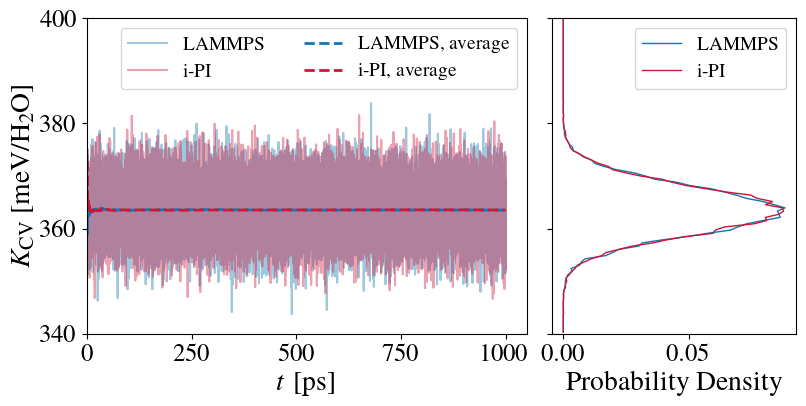

In [19]:
import matplotlib.pyplot as plt
import numpy as np

skip = int(1e0)

# === Figure setup ===
fig, axes = plt.subplots(
    1, 2, figsize=(8, 4),
    width_ratios=[1.8, 1],
    sharey=True,
    facecolor="white",
)
plt.subplots_adjust(wspace=0.05)  # ← reduce horizontal gap (default ~0.2–0.3)

# -------------------------------------------------------
# Left subplot: time evolution of KCV
# -------------------------------------------------------
ax = axes[0]
ax.set_xlabel("$t$ [ps]", fontsize=20)
ax.set_ylabel("$K_{\\mathrm{CV}}$ [meV/H$_2$O]", fontsize=20)
ax.tick_params(axis='both', labelsize=18)

lo, hi = 340, 400

ax.set_xlim(0, 1050)
ax.set_ylim(lo, hi)
ax.set_yticks(list(range(lo, hi+1, 20)))

factor = 1 / natom * 3 * 1e3

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4,
        log_lmp_lan[0][skip:, 14] * factor,
        color=colors[3], alpha=0.4, linestyle="-", label="LAMMPS")
ax.plot(log_ipi[skip:, 0]*5e-4,
        log_ipi[skip:, 6] * factor,
        color=colors[2], alpha=0.4, linestyle="-", label="i-PI")

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4,
        accu_avg(log_lmp_lan[0][skip:, 14]) * factor,
        color=colors[3], alpha=1.0, linestyle="--", linewidth=2,
        label="LAMMPS, average")
ax.plot(log_ipi[skip:, 0]*5e-4,
        accu_avg(log_ipi[skip:, 6]) * factor,
        color=colors[2], alpha=1.0, linestyle="--", linewidth=2,
        label="i-PI, average")

ax.legend(fontsize=14, loc="upper right", ncols=2)

# -------------------------------------------------------
# Right subplot: histogram distributions as lines
# -------------------------------------------------------
ax2 = axes[1]
ax2.set_xlabel("Probability Density", fontsize=20)
ax2.tick_params(axis='both', labelsize=18)

vals_lmp = log_lmp_lan[0][skip:, 14] * factor
vals_ipi = log_ipi[skip:, 6] * factor
bins = np.linspace(lo, hi, 100)

hist_lmp, edges = np.histogram(vals_lmp, bins=bins, density=True)
hist_ipi, _ = np.histogram(vals_ipi, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

ax2.plot(hist_lmp, centers, color=colors[3], lw=1, linestyle="-", label="LAMMPS")
ax2.plot(hist_ipi, centers, color=colors[2], lw=1, linestyle="-", label="i-PI")

ax2.legend(fontsize=14, loc="upper right")

# -------------------------------------------------------
# Final layout
# -------------------------------------------------------
plt.tight_layout(pad=0.5)  # minimal padding around figure
plt.savefig("kcv.pdf")
plt.show()


In [20]:
temp_log_lmp_lan = np.array(list(log_lmp_lan.values()))[:, :, 1].mean(axis=0)/32

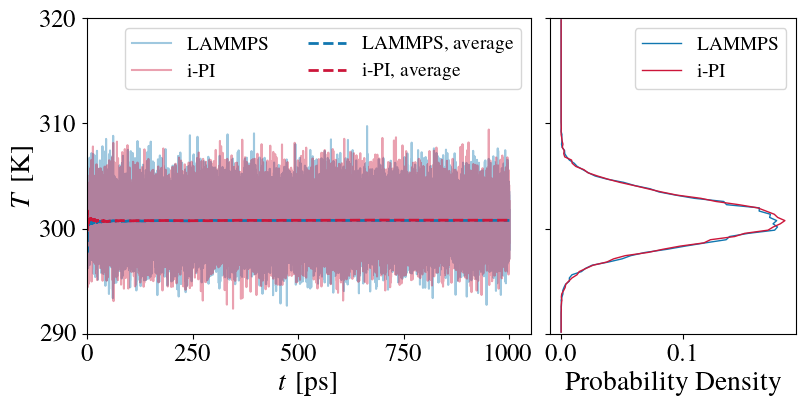

In [21]:
import matplotlib.pyplot as plt
import numpy as np

skip = int(1e0)

# === Figure setup ===
fig, axes = plt.subplots(
    1, 2, figsize=(8, 4),
    width_ratios=[1.8, 1],
    sharey=True,
    facecolor="white",
)
plt.subplots_adjust(wspace=0.05)  # reduce horizontal gap

# -------------------------------------------------------
# Left subplot: time evolution of temperature
# -------------------------------------------------------
ax = axes[0]
ax.set_xlabel("$t$ [ps]", fontsize=20)
ax.set_ylabel("$T$ [K]", fontsize=20)
ax.tick_params(axis='both', labelsize=18)

lo, hi = 290, 320
ax.set_xlim(0, 1050)
ax.set_ylim(lo, hi)
ax.set_yticks(list(range(lo, hi+1, 10)))

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4,
        temp_log_lmp_lan[skip:],
        color=colors[3], alpha=0.4, linestyle="-", label="LAMMPS")
ax.plot(log_ipi[skip:, 0]*5e-4,
        log_ipi[skip:, 3],
        color=colors[2], alpha=0.4, linestyle="-", label="i-PI")

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4,
        accu_avg(temp_log_lmp_lan[skip:]),
        color=colors[3], alpha=1.0, linestyle="--", linewidth=2,
        label="LAMMPS, average")
ax.plot(log_ipi[skip:, 0]*5e-4,
        accu_avg(log_ipi[skip:, 3]),
        color=colors[2], alpha=1.0, linestyle="--", linewidth=2,
        label="i-PI, average")

ax.legend(fontsize=14, loc="upper right", ncols=2)

# -------------------------------------------------------
# Right subplot: histogram distributions as lines
# -------------------------------------------------------
ax2 = axes[1]
ax2.set_xlabel("Probability Density", fontsize=20)
ax2.tick_params(axis='both', labelsize=18)

vals_lmp = temp_log_lmp_lan[skip:]
vals_ipi = log_ipi[skip:, 3]
bins = np.linspace(lo, hi, 100)

hist_lmp, edges = np.histogram(vals_lmp, bins=bins, density=True)
hist_ipi, _ = np.histogram(vals_ipi, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

ax2.plot(hist_lmp, centers, color=colors[3], lw=1, linestyle="-", label="LAMMPS")
ax2.plot(hist_ipi, centers, color=colors[2], lw=1, linestyle="-", label="i-PI")

ax2.legend(fontsize=14, loc="upper right")

# -------------------------------------------------------
# Final layout
# -------------------------------------------------------
plt.tight_layout(pad=0.5)
plt.savefig("temperature.pdf")
plt.show()


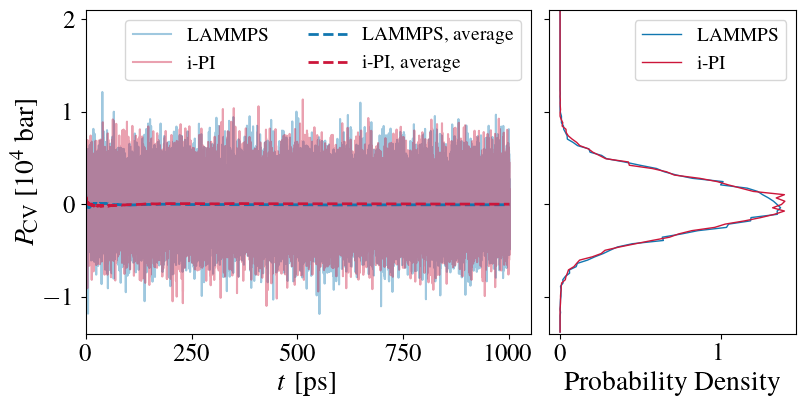

In [22]:
import matplotlib.pyplot as plt
import numpy as np

skip = int(1e0)

# === Figure setup ===
fig, axes = plt.subplots(
    1, 2, figsize=(8, 4),
    width_ratios=[1.8, 1],
    sharey=True,
    facecolor="white",
)
plt.subplots_adjust(wspace=0.05)  # reduce horizontal gap

# -------------------------------------------------------
# Left subplot: time evolution of PCV
# -------------------------------------------------------
ax = axes[0]
ax.set_xlabel("$t$ [ps]", fontsize=20)
ax.set_ylabel("$P_{\\mathrm{CV}}$ [$10^4$ bar]", fontsize=20)
ax.tick_params(axis='both', labelsize=18)

factor = 1e-4

lo, hi = -1.4e4 * factor, 2.1e4 * factor
ax.set_xlim(0, 1050)
ax.set_yticks(list(range(int(-2e4 * factor), int(6e4 * factor), int(1e4 * factor))))
ax.set_ylim(lo, hi)

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4,
        log_lmp_lan[0][skip:, 17] * factor,
        color=colors[3], alpha=0.4, linestyle="-", label="LAMMPS")
ax.plot(log_ipi[skip:, 0]*5e-4,
        log_ipi[skip:, 8] * factor,
        color=colors[2], alpha=0.4, linestyle="-", label="i-PI")

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4,
        accu_avg(log_lmp_lan[0][skip:, 17]) * factor,
        color=colors[3], alpha=1.0, linestyle="--", linewidth=2,
        label="LAMMPS, average")
ax.plot(log_ipi[skip:, 0]*5e-4,
        accu_avg(log_ipi[skip:, 8]) * factor,
        color=colors[2], alpha=1.0, linestyle="--", linewidth=2,
        label="i-PI, average")

ax.legend(fontsize=14, loc="upper right", ncols=2)

# -------------------------------------------------------
# Right subplot: histogram distributions as lines
# -------------------------------------------------------
ax2 = axes[1]
ax2.set_xlabel("Probability Density", fontsize=20)
ax2.tick_params(axis='both', labelsize=18)

vals_lmp = log_lmp_lan[0][skip:, 17] * factor
vals_ipi = log_ipi[skip:, 8] * factor
bins = np.linspace(lo, hi, 100)

hist_lmp, edges = np.histogram(vals_lmp, bins=bins, density=True)
hist_ipi, _ = np.histogram(vals_ipi, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

ax2.plot(hist_lmp, centers, color=colors[3], lw=1, linestyle="-", label="LAMMPS")
ax2.plot(hist_ipi, centers, color=colors[2], lw=1, linestyle="-", label="i-PI")

ax2.legend(fontsize=14, loc="upper right")

# -------------------------------------------------------
# Final layout
# -------------------------------------------------------
plt.tight_layout(pad=0.5)
plt.savefig("pcv.pdf")
plt.show()


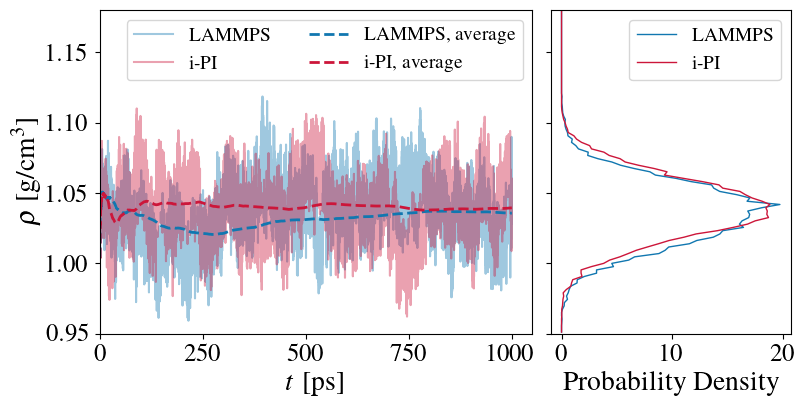

In [23]:
skip = int(0e0)

dense_lmp = dens_from_vol(log_lmp_lan[0][skip:, 3])
dense_lmp_avg = np.cumsum(dense_lmp)/(1+np.arange(dense_lmp.shape[0]))

dense_ipi = dens_from_vol(log_ipi[skip:, -1])
dense_ipi_avg = np.cumsum(dense_ipi)/(1+np.arange(dense_ipi.shape[0]))

# === Figure setup ===
fig, axes = plt.subplots(
    1, 2, figsize=(8, 4),
    width_ratios=[1.8, 1],
    sharey=True,
    facecolor="white",
)
plt.subplots_adjust(wspace=0.05)  # reduce horizontal gap

# -------------------------------------------------------
# Left subplot: time evolution of density
# -------------------------------------------------------
ax = axes[0]
ax.set_xlabel("$t$ [ps]", fontsize=20)
ax.set_ylabel("$\\rho$ [g/cm$^3$]", fontsize=20)
ax.tick_params(axis='both', labelsize=18)

lo, hi = 0.95, 1.18

ax.set_xlim(0, 1050)
ax.set_ylim(lo, hi)

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4, dense_lmp,
        color=colors[3], alpha=0.4, linestyle="-", label="LAMMPS")
ax.plot(log_ipi[skip:, 0]*5e-4, dense_ipi,
        color=colors[2], alpha=0.4, linestyle="-", label="i-PI")

ax.plot(log_lmp_lan[0][skip:, 0]*5e-4, dense_lmp_avg,
        color=colors[3], alpha=1.0, linestyle="--", linewidth=2, label="LAMMPS, average")
ax.plot(log_ipi[skip:, 0]*5e-4, dense_ipi_avg,
        color=colors[2], alpha=1.0, linestyle="--", linewidth=2, label="i-PI, average")

ax.legend(fontsize=14, loc="upper right", ncols=2)

# -------------------------------------------------------
# Right subplot: histogram distributions as lines
# -------------------------------------------------------
ax2 = axes[1]
ax2.set_xlabel("Probability Density", fontsize=20)
ax2.tick_params(axis='both', labelsize=18)

vals_lmp = dense_lmp
vals_ipi = dense_ipi
bins = np.linspace(lo, hi, 100)

hist_lmp, edges = np.histogram(vals_lmp, bins=bins, density=True)
hist_ipi, _ = np.histogram(vals_ipi, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

ax2.plot(hist_lmp, centers, color=colors[3], lw=1, linestyle="-", label="LAMMPS")
ax2.plot(hist_ipi, centers, color=colors[2], lw=1, linestyle="-", label="i-PI")

ax2.legend(fontsize=14, loc="upper right")

# -------------------------------------------------------
# Final layout
# -------------------------------------------------------
plt.tight_layout(pad=0.5)
plt.savefig("density.pdf")
plt.show()


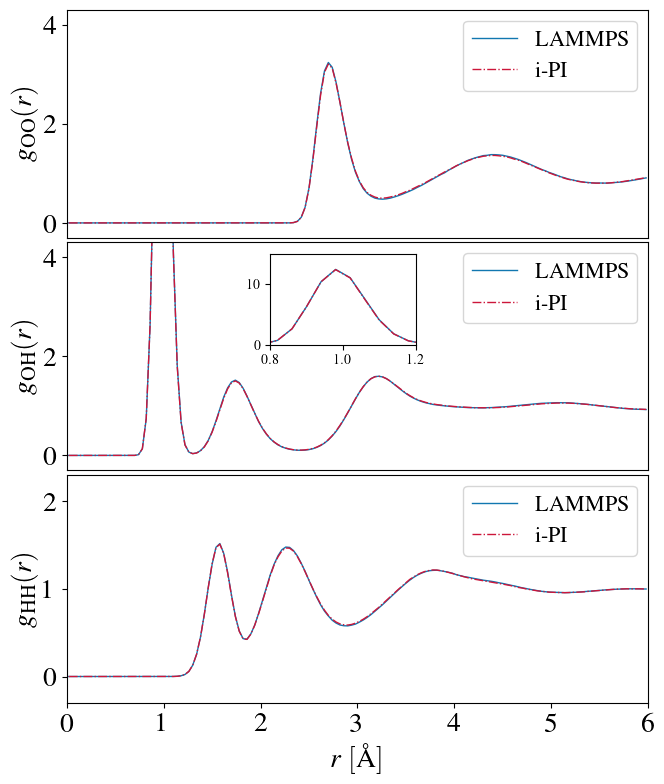

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(3, 1, figsize=(7.5, 9), facecolor="white")
fig.subplots_adjust(hspace=0.02)

xlo = 0.0
xhi = 6.0
ylo = -0.3
yhi = 4.3
yhi2 = 2.3

# --- gOO ---
ax = axes[0]
# ax.set_title("Liquid Water, 128 H$_2$O, 300 K, $NVT$", fontsize=20)
ax.set_xlim(xlo, xhi)   # start from 0
ax.set_ylim(ylo, yhi)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # hide x ticks
ax.tick_params(axis='y', labelsize=20)
ax.set_ylabel("$g_{\\mathrm{OO}}(r)$", fontsize=20)

ax.plot(goo_lmp_lan_liq[0, :, 0], goo_lmp_lan_liq_mean, color=colors[3], linewidth=1.0, linestyle="-", label="LAMMPS")
ax.plot(goo_lmp_ipi_liq[0, :, 0], goo_lmp_ipi_liq_mean, color=colors[2], linewidth=1.0, linestyle="-.", label="i-PI")
ax.legend(fontsize=16, loc="upper right")

# --- gOH ---
ax = axes[1]
ax.set_xlim(xlo, xhi)
ax.set_ylim(ylo, yhi)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # hide x ticks
ax.tick_params(axis='y', labelsize=20)
ax.set_ylabel("$g_{\\mathrm{OH}}(r)$", fontsize=20)

ax.plot(goh_lmp_lan_liq[0, :, 0], goh_lmp_lan_liq_mean, color=colors[3], linewidth=1.0, linestyle="-", label="LAMMPS")
ax.plot(goh_lmp_ipi_liq[0, :, 0], goh_lmp_ipi_liq_mean, color=colors[2], linewidth=1.0, linestyle="-.", label="i-PI")
ax.legend(fontsize=16)

# inset for gOH
axins = inset_axes(
    ax,
    width="25%",    # same as 0.25 of parent width
    height="40%",   # same as 0.4 of parent height
    bbox_to_anchor=(0.35, 0.55, 1, 1),
    bbox_transform=ax.transAxes,
    loc='lower left',  # position reference corner
    borderpad=0
)
# axins = inset_axes(ax, width="30%", height="30%", loc="upper right")
# axins.set_axes_locator(ip)
axins.set_xlim(0.8, 1.2)
axins.set_ylim(-0.01, 15.0)
axins.plot(goh_lmp_lan_liq[0, :, 0], goh_lmp_lan_liq_mean, color=colors[3], linewidth=1.0, linestyle="-")
axins.plot(goh_lmp_ipi_liq[0, :, 0], goh_lmp_ipi_liq_mean, color=colors[2], linewidth=1.0, linestyle="-.")

# --- gHH ---
ax = axes[2]
ax.set_xlim(xlo, xhi)
ax.set_ylim(ylo, yhi2)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel("$r\\ [\\mathrm{\\AA}]$", fontsize=20)
ax.set_ylabel("$g_{\\mathrm{HH}}(r)$", fontsize=20)

ax.plot(ghh_lmp_lan_liq[0, :, 0], ghh_lmp_lan_liq_mean, color=colors[3], linewidth=1.0, linestyle="-", label="LAMMPS")
ax.plot(ghh_lmp_ipi_liq[0, :, 0], ghh_lmp_ipi_liq_mean, color=colors[2], linewidth=1.0, linestyle="-.", label="i-PI")
ax.legend(fontsize=16)

# plt.tight_layout()
plt.savefig("rdf_liquid_water.pdf", bbox_inches='tight', pad_inches=0.02)
plt.show()
